# Finding convergence parameters in AlGaO$_\mathbf{3}$ DOS calculations

For this example we use a data set of 144 calculations of AlGaO$_3$ that were done with FHI-aims using different numerical settings and approximations. The data was produced for Ref. [1]. The data is hosted at [NOMAD](https://nomad-lab.eu/nomad-lab/) and can be downloaded using `MADAS`.

To do so we first define the query:

In [2]:
AlGaO_query = {
    "datasets.dataset_name:any": [
      "Numerical_Errors_FHI-aims"
    ],
    "results.material.elements:all": [
      "Al",
      "O",
      "Ga"
    ],
    "results.properties.available_properties:all": [
      "dos_electronic"
    ]
  }

We use the NOMAD API in `MADAS`:

In [3]:
from madas.apis.NOMAD_web_API import API

The values are extracted from the NOMAD Archives using the [following functions](https://github.com/kubanmar/madas-examples/blob/master/notebooks/processing_functions.py):

In [4]:
from processing_functions import get_dos_values, get_dos_energies_vbm, get_FHIaims_kpoints, get_FHIaims_n_basis_functions

In [5]:
processing = API().processing
processing.pop("archive")
processing["electronic_dos_values"] = get_dos_values
processing["electronic_dos_energies"] = get_dos_energies_vbm
processing["kpoints"] = get_FHIaims_kpoints
processing["n_basis_functions"] = get_FHIaims_n_basis_functions

Next we define our database for storing the data:

In [6]:
from madas import MaterialsDatabase

In [7]:
db=MaterialsDatabase(filename="AlGaO_convergence.db", 
                     api=API(processing=processing))

In [23]:
%%time
db.fill_database(AlGaO_query)

2026-08-02 15:15:31,733 - AlGaO_convergence_log - INFO - Query has already been performed.


CPU times: user 1.22 ms, sys: 5 μs, total: 1.22 ms
Wall time: 2.41 ms


In case some data could not be retrieved, we can retry them:

In [9]:
materials_retry = db.api.retry()
if len(materials_retry) > 0:
    db.backend.add_many(materials_retry)

2026-08-02 15:07:34,093 - AlGaO_convergence_api - INFO - Retrying 74 entries.
2026-08-02 15:07:44,941 - AlGaO_convergence_api - ERROR - Retry failed for material with entry_id fuvRcgYe6FP0E3fah4NmGxZLs1BK. Error message: 'data'
2026-08-02 15:07:45,105 - AlGaO_convergence_api - ERROR - Retry failed for material with entry_id 4dQllCv7iSHJ6A3J0Kt5asYlHks7. Error message: 'data'
2026-08-02 15:07:45,248 - AlGaO_convergence_api - ERROR - Retry failed for material with entry_id 968e9a1qCmMezGEeDAPVLJ6f9jD7. Error message: 'data'
2026-08-02 15:07:45,953 - AlGaO_convergence_api - ERROR - Retry failed for material with entry_id unmGiAwhzixk_ijIeO5-q5EFBQiT. Error message: 'data'
2026-08-02 15:07:46,090 - AlGaO_convergence_api - ERROR - Retry failed for material with entry_id RV5_4NjapFpwDmeiKyVzCqcaIRuP. Error message: 'data'
2026-08-02 15:07:49,048 - AlGaO_convergence_api - ERROR - Retry failed for material with entry_id duFzoDAKG95t7FqGz2hQ2yzkz63a. Error message: 'data'
2026-08-02 15:07:49,19

Eventually, $144$ entries should be downloaded:

In [24]:
len(db)

108

We then start generating fingerprints:

In [11]:
from madas.fingerprints import DOSFingerprint

We generate a grid for the DOS fingerprint [2] with a high number of pixels and a large energy range:

In [12]:
grid = DOSFingerprint.get_default_grid().create(n_pix=2048, cutoff=[-8, 12])

We add the fingerprints to the database:

In [13]:
db.add_fingerprint("DOS", fingerprint_kwargs={"grid_id":grid.get_grid_id()})

2026-08-02 15:08:02,711 - AlGaO_convergence_log - INFO - Generating DOS fingerprints...
2026-08-02 15:08:02,716 - AlGaO_convergence_log - INFO - Generating "DOS" fingerprints.


  0%|          | 0/108 [00:00<?, ?it/s]

2026-08-02 15:10:01,236 - AlGaO_convergence_log - INFO - Writing DOS fingerprints to database...
2026-08-02 15:10:02,762 - AlGaO_convergence_log - INFO - Finished generation of DOS fingerprints.


And compute a similarity matrix from these fingerprints:

In [14]:
simat = db.get_similarity_matrix("DOS", name="DOS")

2026-08-02 15:10:02,801 - AlGaO_convergence_log - INFO - Fingerprints with name "DOS" exist. Reading from database.


  0%|          | 0/108 [00:00<?, ?it/s]

We sort the entries by mean similarity to the rest of the data set by taking the mean of each row of the similarity matrix.

In [15]:
import numpy as np
# tqdm progress bar for visualization of the progress 
from madas.utils import tqdm

In [16]:
sorted_mids = list(sorted(simat.mids, key = lambda x: np.mean(simat[x])))

In [17]:
nfunc, kpoints = [], []
for mid in tqdm(sorted_mids):
    entry = db[mid]
    nfunc.append(entry.data["n_basis_functions"])
    kpoints.append(np.prod(entry.data["kpoints"]))

  0%|          | 0/108 [00:00<?, ?it/s]

In [18]:
import matplotlib.pyplot as plt
from plotting_functions import similarity_kpoint_nfunc_plot
plt.style.use("./settings.mplstyle")

/home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/plotting_functions.py:78: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("E$_\mathrm{ref}$ [eV]")
/home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/plotting_functions.py:135: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(kpoints, label="N$_\mathrm{kpt}$")
/home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/plotting_functions.py:136: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(range(len(kpoints)),nfunc,label="N$_\mathrm{func}$")


In [19]:
# sort the matrix
simat.get_sub_matrix(sorted_mids, copy=False)

SimilarityMatrix(DOS, DOS, 108)

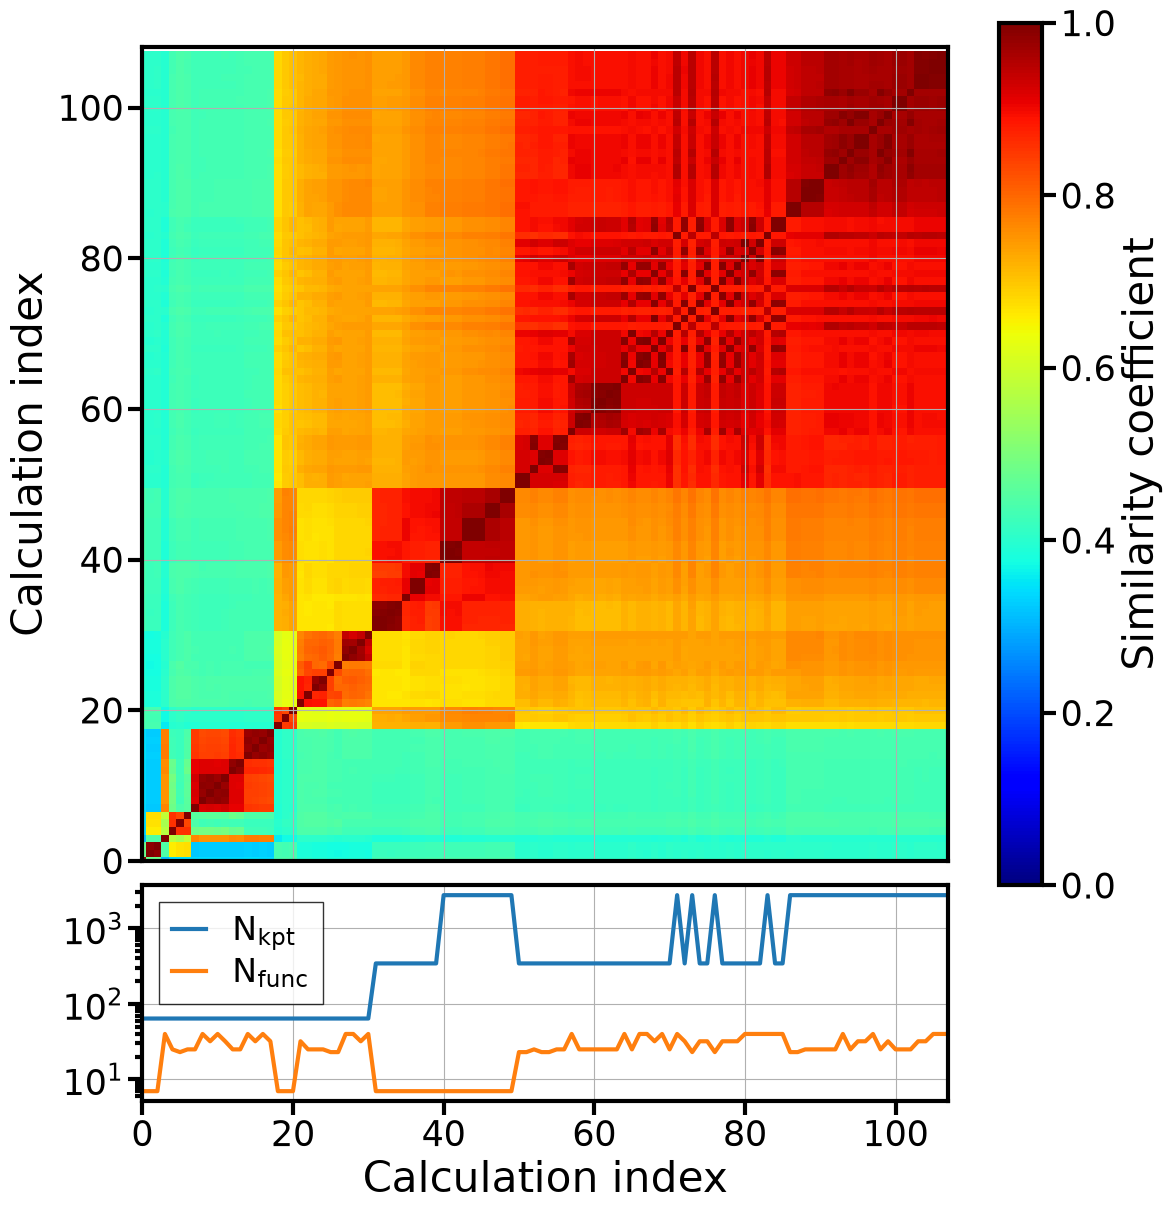

In [20]:
similarity_kpoint_nfunc_plot(simat, kpoints, nfunc, filename=None, cmap="jet")

## References

[1] Carbogno, C., Thygesen, K.S., Bieniek, B. et al. Numerical quality control for DFT-based materials databases. npj Comput Mater 8, 69 (2022). https://doi.org/10.1038/s41524-022-00744-4

[2] Kuban, M., Rigamonti, S., Scheidgen, M. et al. Density-of-states similarity descriptor for unsupervised learning from materials data. Sci Data 9, 646 (2022). https://doi.org/10.1038/s41597-022-01754-z